# Homework 2: Initial EDA
This notebook performs an initial exploratory data analysis for the irrigation need prediction competition. The goal is to understand the dataset, identify important features, check for data quality issues, and surface early modeling insights.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', font_scale=1.1)

train_path = '../Kaggle/train.csv'
test_path = '../Kaggle/test.csv'

train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Train columns:', train.columns.tolist())

Train shape: (630000, 21)
Test shape: (270000, 20)
Train columns: ['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']


In [14]:
# Basic preview and missing value check
train.head(5)

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [15]:
print('Missing values by column:')
print(train.isna().sum())

print('\nTarget distribution:')
print(train['Irrigation_Need'].value_counts(normalize=True).rename('proportion'))

print('\nCategorical counts:')
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
for col in cat_cols:
    print(f'\n{col}:', train[col].nunique())
    print(train[col].value_counts().head(5))

Missing values by column:
id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

Target distribution:
Irrigation_Need
Low       0.587170
Medium    0.379483
High      0.033348
Name: proportion, dtype: float64

Categorical counts:

Soil_Type: 4
Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64

Crop_Type: 6
Crop_Type
Sugarcane    108910
Rice         106697
Cotton       104645
Maize

In [20]:
# Numeric summary by target category for initial feature separation
numeric_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
                'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
                'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
target_order = ['Low', 'Medium', 'High']

summary = train.groupby('Irrigation_Need')[numeric_cols].mean().reindex(target_order).T
summary

Irrigation_Need,Low,Medium,High
Soil_pH,6.487805,6.465867,6.578282
Soil_Moisture,43.305902,29.743961,17.669875
Organic_Carbon,0.920680,0.926116,0.924143
Electrical_Conductivity,1.731755,1.769208,1.690880
Temperature_C,25.347708,28.886683,34.568134
Humidity,61.949194,61.004887,61.119576
Rainfall_mm,1500.534313,1444.475028,989.156678
Sunlight_Hours,7.511125,7.521290,7.463138
Wind_Speed_kmh,9.216424,11.793668,14.642639
Field_Area_hectare,7.447241,7.625725,7.530391


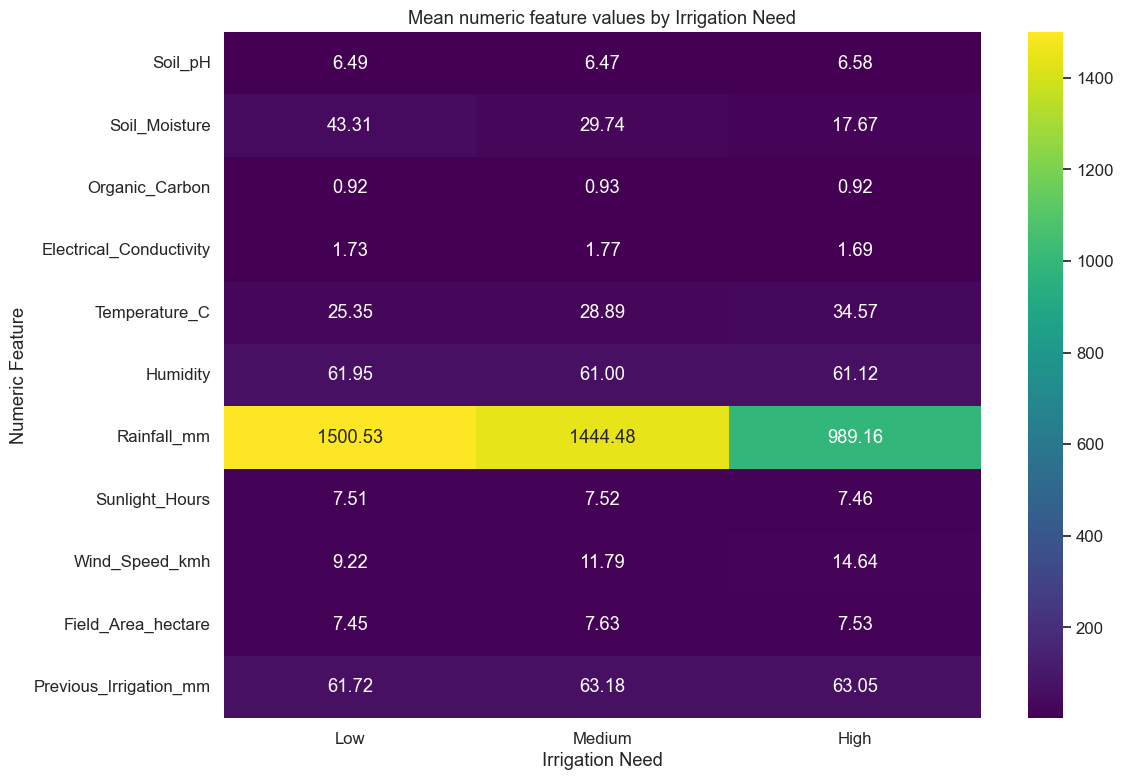

In [21]:
# A quick heatmap-style view of mean values by target
plt.figure(figsize=(12, 8))
sns.heatmap(summary, annot=True, fmt='.2f', cmap='viridis')
plt.title('Mean numeric feature values by Irrigation Need')
plt.xlabel('Irrigation Need')
plt.ylabel('Numeric Feature')
plt.tight_layout()
plt.show()

C:\Users\tyler\AppData\Local\Temp\ipykernel_13076\1015547334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Irrigation_Need', y=col, order=target_order, palette='viridis')
C:\Users\tyler\AppData\Local\Temp\ipykernel_13076\1015547334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Irrigation_Need', y=col, order=target_order, palette='viridis')
C:\Users\tyler\AppData\Local\Temp\ipykernel_13076\1015547334.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Irrigation_Need', y=col, order=targ

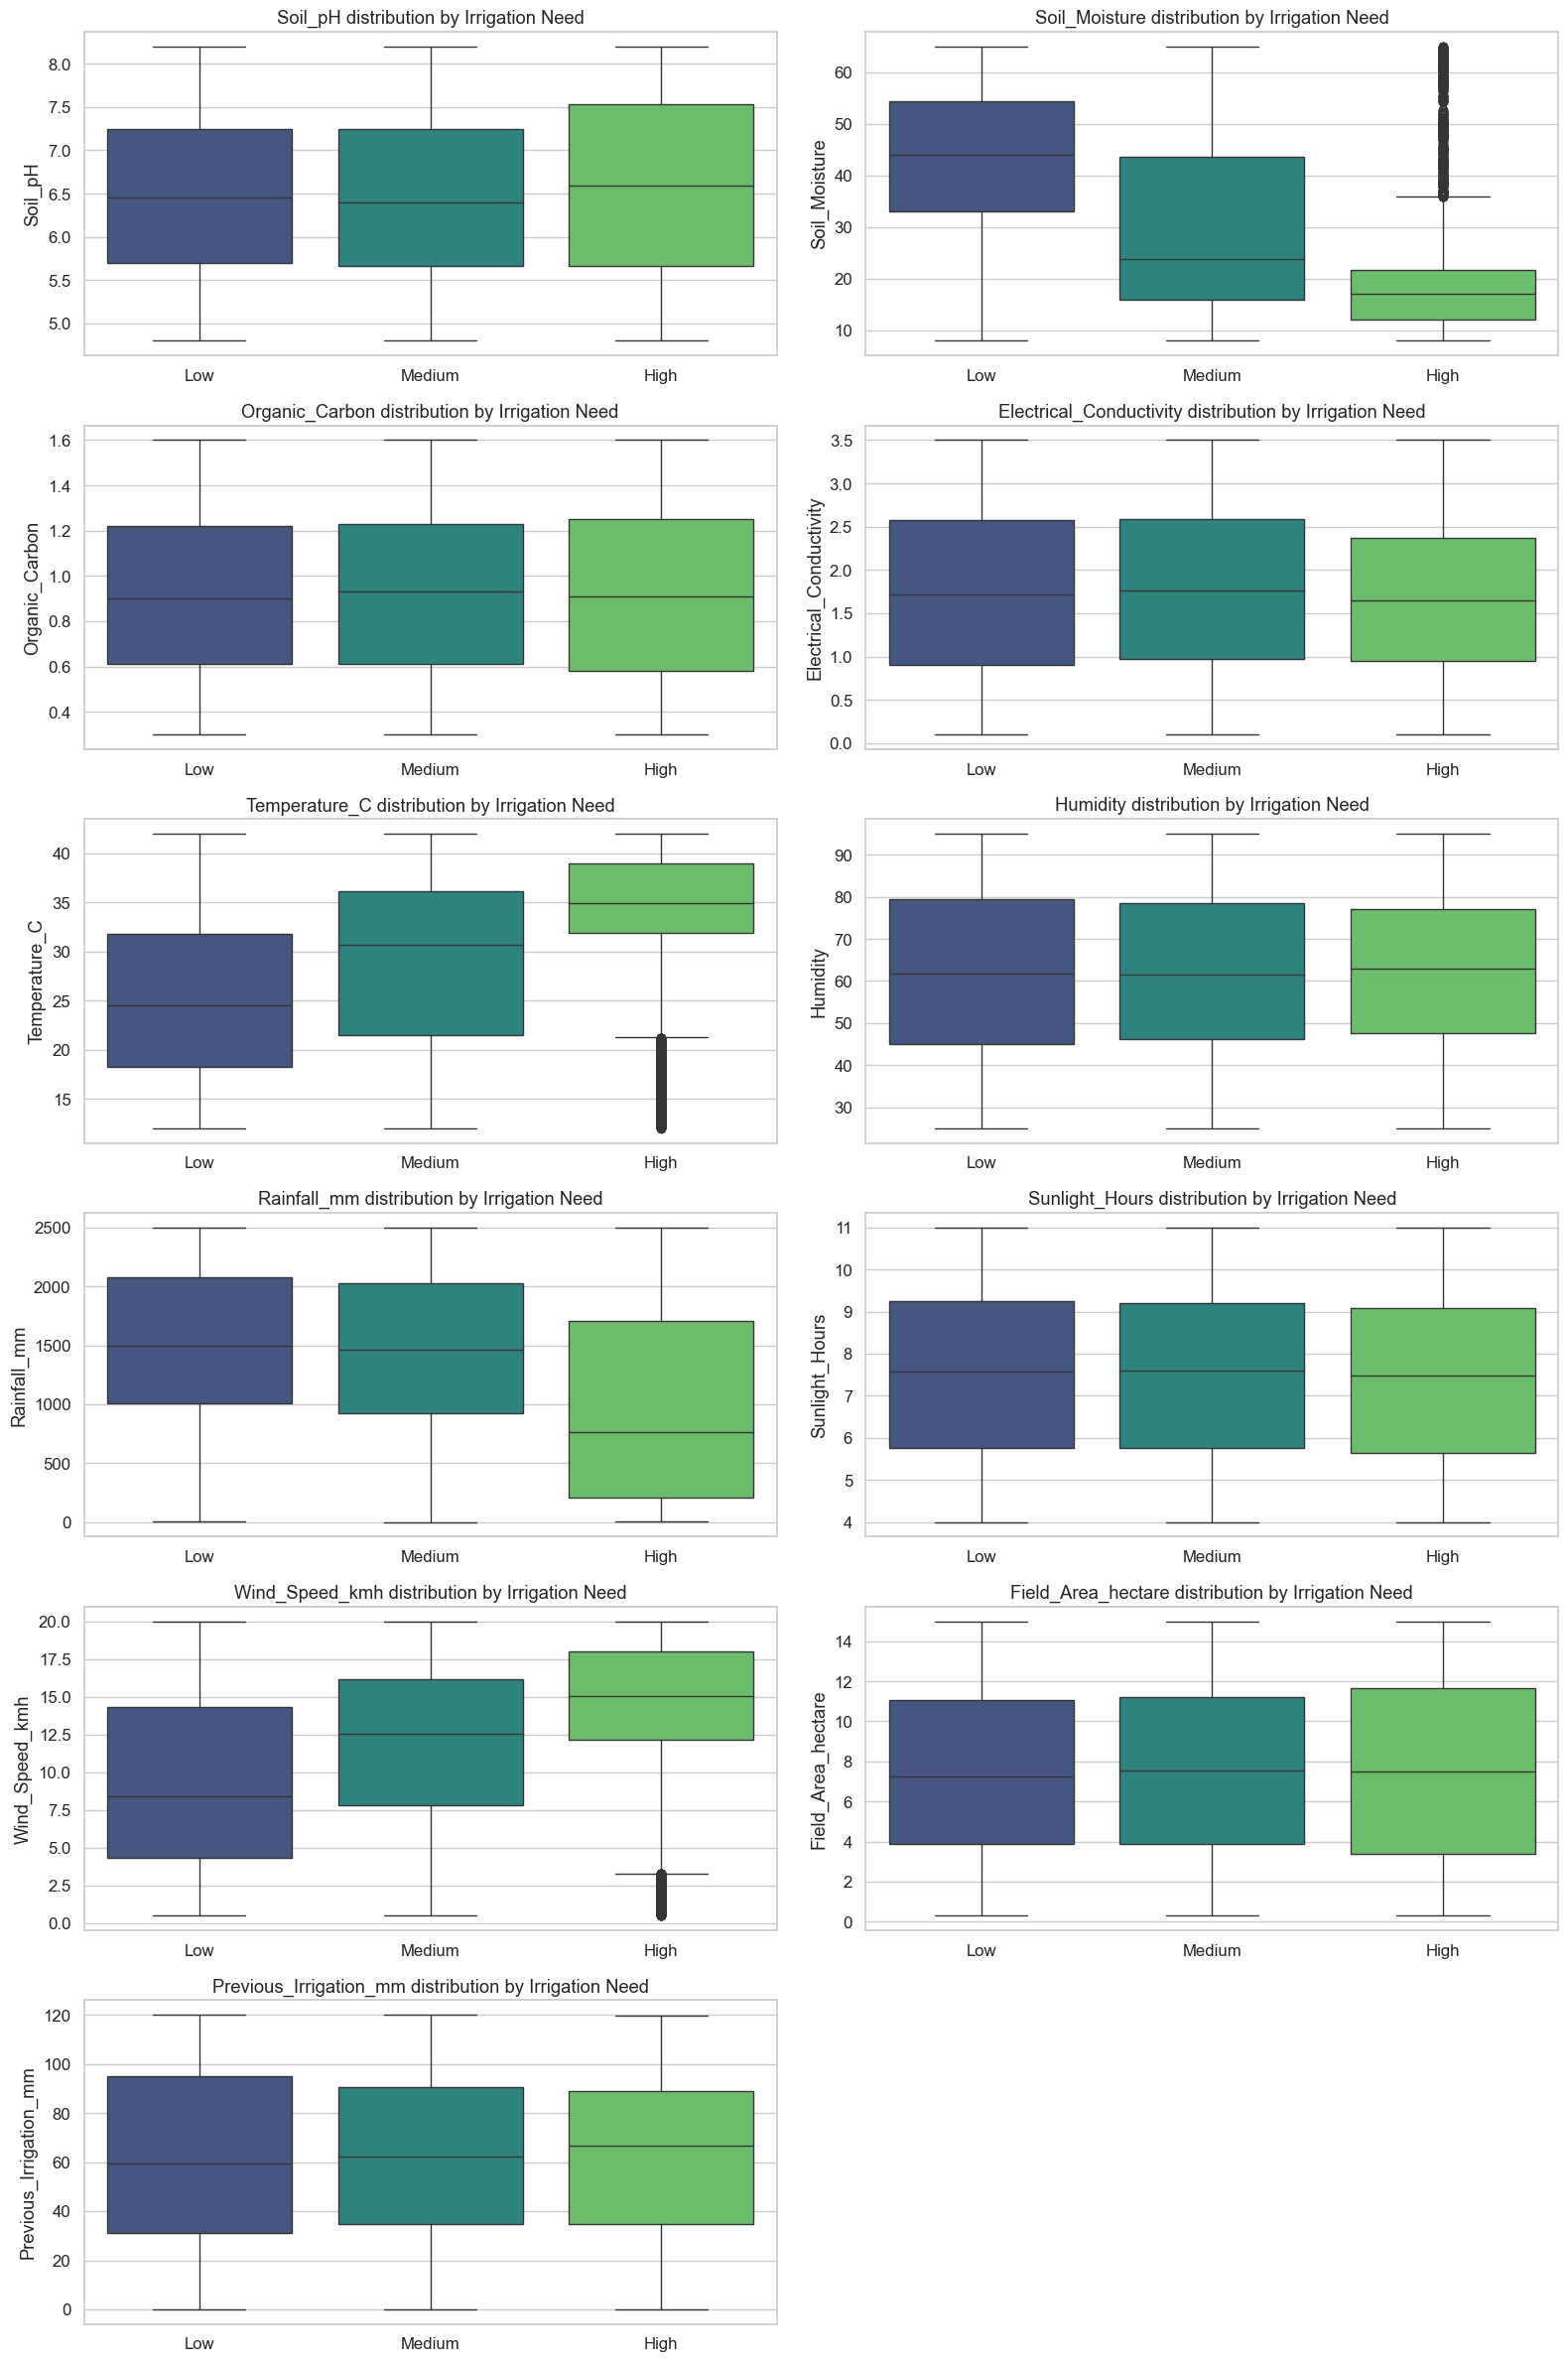

In [22]:
# Box and whisker plots for numeric feature distributions by target
plt.figure(figsize=(16, 24))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(6, 2, i)
    sns.boxplot(data=train, x='Irrigation_Need', y=col, order=target_order, palette='viridis')
    plt.title(f'{col} distribution by Irrigation Need')
    plt.xlabel('')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

<Figure size 1000x400 with 0 Axes>

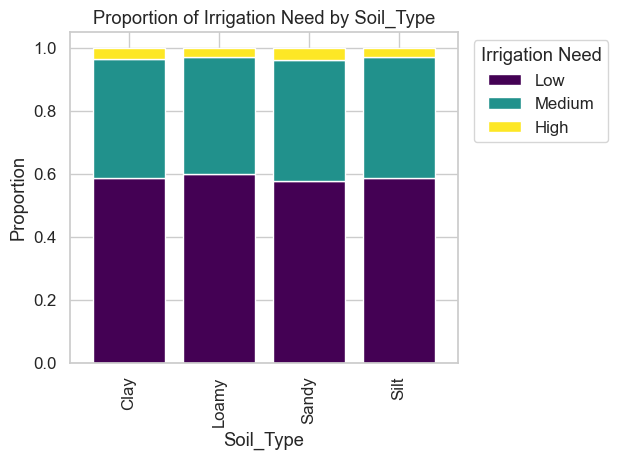

<Figure size 1000x400 with 0 Axes>

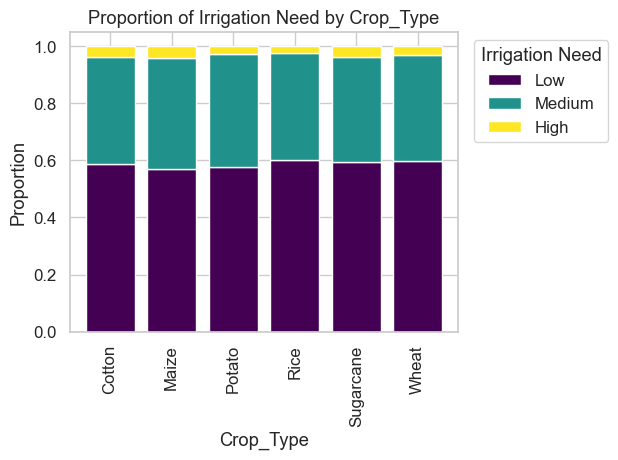

<Figure size 1000x400 with 0 Axes>

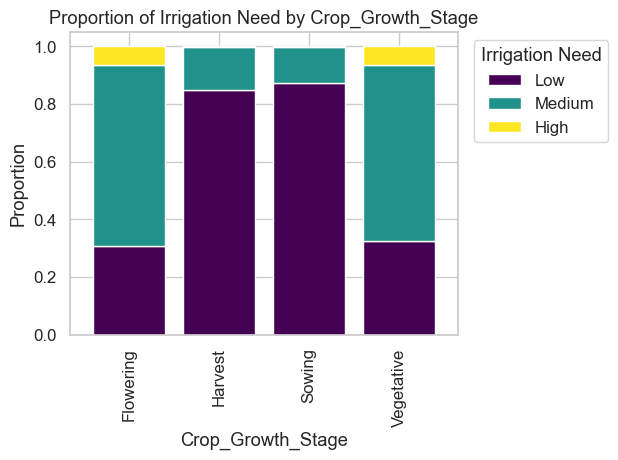

<Figure size 1000x400 with 0 Axes>

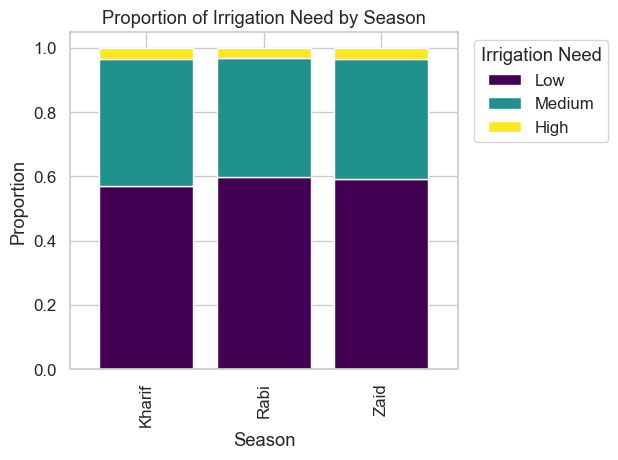

<Figure size 1000x400 with 0 Axes>

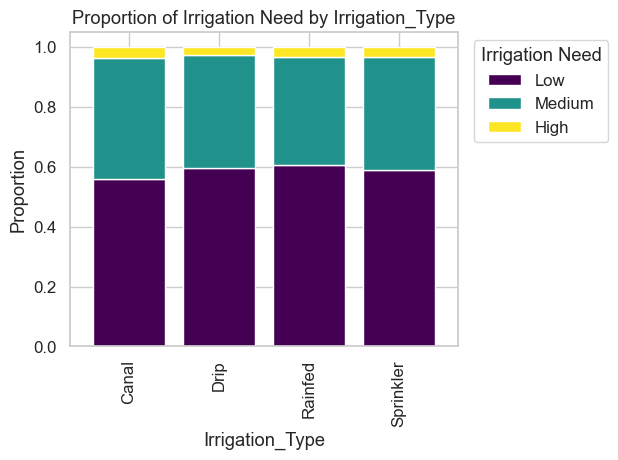

<Figure size 1000x400 with 0 Axes>

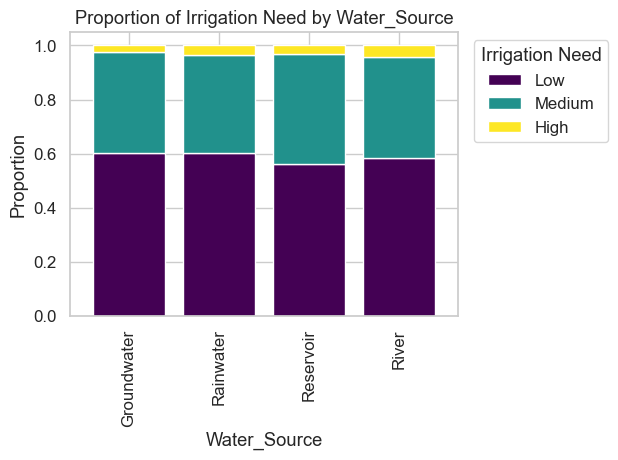

<Figure size 1000x400 with 0 Axes>

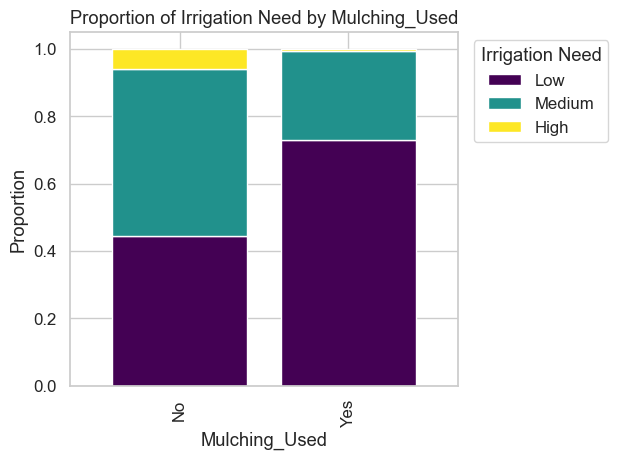

<Figure size 1000x400 with 0 Axes>

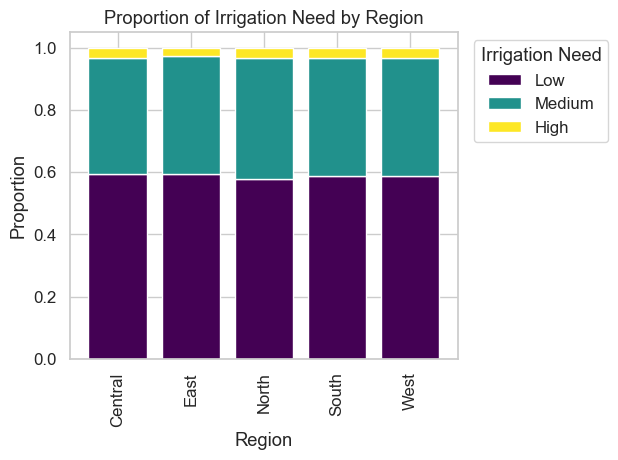

In [18]:
# Top categorical breakdowns for the target classes
for col in cat_cols:
    plt.figure(figsize=(10, 4))
    proportion_df = train.groupby(col)['Irrigation_Need'].value_counts(normalize=True).unstack().fillna(0)
    proportion_df[target_order].plot(kind='bar', stacked=True, colormap='viridis', width=0.8)
    plt.title(f'Proportion of Irrigation Need by {col}')
    plt.ylabel('Proportion')
    plt.legend(title='Irrigation Need', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## Key insights from initial EDA
- The training set has 630,000 rows and no missing values, so data quality is strong at a first glance.
- The target is imbalanced: `Low` is the majority class, `Medium` is common, and `High` is relatively rare.
- Numeric features show strong signal for `High` need in particular:
  - `Soil_Moisture` is much lower for `High` need.
  - `Temperature_C` and `Wind_Speed_kmh` are higher for `High` need.
  - `Rainfall_mm` is lower on average for `High` need, which fits an irrigation requirement expectation.
- Categorical fields also appear meaningful:
  - `Crop_Growth_Stage` is strongly associated with need: `Flowering` and `Vegetative` stages have more `High` and `Medium` labels.
  - `Season` and `Irrigation_Type` show different risk profiles, suggesting climate and irrigation infrastructure matter.
  - `Mulching_Used` splits the data: `No` tends to have more `Medium` and `High` demand, which may mean mulching reduces irrigation need.

## Most important features so far
- `Soil_Moisture`
- `Rainfall_mm`
- `Temperature_C`
- `Crop_Growth_Stage`
- `Mulching_Used`
- `Irrigation_Type`

These features are especially promising because they align with domain expectations and show clear separation by `Irrigation_Need`.

## Potential issues and next steps
- The target imbalance may require class-weighted modeling, oversampling, or specialized metrics such as macro F1.
- Some categorical variables have many levels in the test set, so consistent encoding is important.
- `Field_Area_hectare` and `Previous_Irrigation_mm` have wide ranges; scaling or transformation may help for some models.
- I would like to compare this notebook with the Kaggle inspiration notebook for plot style and feature engineering ideas.
- Next steps:
  - Create feature interactions between weather and crop stage.
  - Add feature importance analysis with a tree-based model.
  - Evaluate whether `Region` and `Season` improve predictions after accounting for numeric signals.